In [1]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
class RWFDataset(Dataset):
    def __init__(self, root, frames=16):
        self.samples = []
        self.frames = frames

        for label, cls in enumerate(["NonFight", "Fight"]):
            folder = os.path.join(root, cls)
            for file in os.listdir(folder):
                if file.endswith(".avi") or file.endswith(".mp4"):
                    self.samples.append((os.path.join(folder, file), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        cap = cv2.VideoCapture(path)
        frames = []

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.resize(frame, (224,224))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        cap.release()

        if len(frames) == 0:
            frames = [np.zeros((224,224,3), dtype=np.uint8)]

        if len(frames) >= self.frames:
            idxs = np.linspace(0, len(frames)-1, self.frames).astype(int)
            frames = [frames[i] for i in idxs]
        else:
            frames += [frames[-1]] * (self.frames - len(frames))

        # ImageNet normalization
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        clip = (np.array(frames)/255.0 - mean) / std

        clip = torch.tensor(clip).permute(0,3,1,2).float()
        return clip, torch.tensor(label, dtype=torch.float32)

In [3]:
class Stage2Model(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights="IMAGENET1K_V1")
        self.cnn = nn.Sequential(*list(base.children())[:-1])
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        B,T,C,H,W = x.shape
        feats = []
        for t in range(T):
            f = self.cnn(x[:,t]).view(B,-1)
            feats.append(f)
        feats = torch.stack(feats,1).mean(1)
        return self.fc(feats)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Stage2Model().to(device)
model.load_state_dict(torch.load("stage2_rwf_epoch_8.pth", map_location=device))
model.eval()

print("Loaded model.")

Loaded model.


In [7]:
val_set = RWFDataset(r"D:\Dtaset fot cctv\RWF-2000\val")
val_loader = DataLoader(val_set, batch_size=4)

In [15]:
correct, total = 0, 0
y_true, y_pred = [], []

with torch.no_grad():
    for clips, labels in val_loader:
        clips, labels = clips.to(device), labels.to(device)
        preds = torch.sigmoid(model(clips)).squeeze()
        preds_bin = (preds > 0.42).float()

        correct += (preds_bin == labels).sum().item()
        total += labels.size(0)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds_bin.cpu().numpy())

print("Validation Accuracy:", correct/total)

Validation Accuracy: 0.8375


In [19]:
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[155  45]
 [ 20 180]]
              precision    recall  f1-score   support

         0.0       0.89      0.78      0.83       200
         1.0       0.80      0.90      0.85       200

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



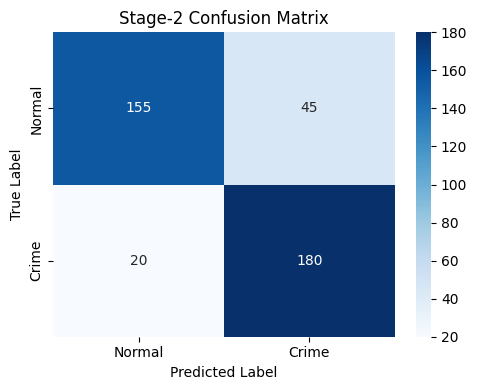

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([[155,45],
               [20,180]])

labels = ["Normal", "Crime"]

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Stage-2 Confusion Matrix")

plt.tight_layout()
plt.savefig("stage2_confusion_matrix.png", dpi=300)
plt.show()